In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---ファイルの読み込むパスを指定---
file_path_left_device = "../../data/raw/wearable/obara_h_left_foot_data.csv"
file_path_right_device = "../../data/raw/wearable/obara_h_right_foot_data.csv"
file_path_mocap = "../../data/raw/mocap/obara_h_mocap.csv"
file_path_force = "../../data/raw/forces/obara_h_force.csv"

# ---CSVファイルの読み込み---
df_left_device = pd.read_csv(file_path_left_device, header=0)
df_right_device = pd.read_csv(file_path_right_device, header=0)
df_mocap = pd.read_csv(file_path_mocap, header=[2, 5, 6])
df_force = pd.read_csv(file_path_force, header=10, encoding='shift_jis')

In [5]:
"""
# ---モーションキャプチャデータの列名を整理---
"""
new_columns = []

for col in df_mocap.columns:
    # col[0]: Rigid Body 001, col[1]: Position, col[2]: X
    
    # 1. FrameとTimeはそのまま
    if col[2] == 'Frame':
        new_columns.append('Frame')
    elif 'Time' in col[2]:
        new_columns.append('Time (Seconds)')
        
    # 2. それ以外は "Rigid Body " を削除して番号だけにする
    else:
        # "Rigid Body " を空文字に置換し、前後の空白も削除
        body_num = col[0].replace('Rigid Body', '').strip()
        
        # 例: 001_Position_X
        name = f"{body_num}_{col[1]}_{col[2]}"
        new_columns.append(name)

# 列名を更新
df_mocap.columns = new_columns

print(df_mocap.columns)

Index(['Frame', 'Time (Seconds)', '001_Rotation_X', '001_Rotation_Y',
       '001_Rotation_Z', '001_Position_X', '001_Position_Y', '001_Position_Z',
       '002_Rotation_X', '002_Rotation_Y', '002_Rotation_Z', '002_Position_X',
       '002_Position_Y', '002_Position_Z', '003_Rotation_X', '003_Rotation_Y',
       '003_Rotation_Z', '003_Position_X', '003_Position_Y', '003_Position_Z',
       '004_Rotation_X', '004_Rotation_Y', '004_Rotation_Z', '004_Position_X',
       '004_Position_Y', '004_Position_Z', '005_Rotation_X', '005_Rotation_Y',
       '005_Rotation_Z', '005_Position_X', '005_Position_Y', '005_Position_Z',
       '006_Rotation_X', '006_Rotation_Y', '006_Rotation_Z', '006_Position_X',
       '006_Position_Y', '006_Position_Z', '007_Rotation_X', '007_Rotation_Y',
       '007_Rotation_Z', '007_Position_X', '007_Position_Y', '007_Position_Z',
       '008_Rotation_X', '008_Rotation_Y', '008_Rotation_Z', '008_Position_X',
       '008_Position_Y', '008_Position_Z', '009_Rotation_X', 

In [6]:
"""
# ---地面反力データの列名を整理---
"""
columns_mapping = {
    'Unnamed: 0': 'Time (Seconds)',
    '右-Fx': 'Right_Fx',
    '右-Fy': 'Right_Fy',
    '右-Fz': 'Right_Fz',
    '右-Mx': 'Right_Mx',
    '右-My': 'Right_My',
    '右-Mz': 'Right_Mz',
    '右-COPx': 'Right_COPx',
    '右-COPy': 'Right_COPy',
    '左-Fx': 'Left_Fx',
    '左-Fy': 'Left_Fy',
    '左-Fz': 'Left_Fz',
    '左-Mx': 'Left_Mx',
    '左-My': 'Left_My',
    '左-Mz': 'Left_Mz',
    '左-COPx': 'Left_COPx',
    '左-COPy': 'Left_COPy',
    '右-速度計': 'Right_SpeedMeter',
    '左-速度計': 'Left_SpeedMeter',
    '右-外部制御': 'Right_ExtControl',
    '左-外部制御': 'Left_ExtControl',
    '右-速度': 'Right_Speed',
    '左-速度': 'Left_Speed',
    '右-実速度': 'Right_ActualSpeed',
    '左-実速度': 'Left_ActualSpeed',
    '右-実効負荷率': 'Right_EffLoadRatio',
    '右-ピーク負荷率': 'Right_PeakLoadRatio',
    '右-消費電力': 'Right_Power',
    '左-実効負荷率': 'Left_EffLoadRatio',
    '左-ピーク負荷率': 'Left_PeakLoadRatio',
    '左-消費電力': 'Left_Power',
    'アナログ入力1': 'Analog1'
}

df_force = df_force.rename(columns=columns_mapping)
print(df_force.columns)

Index(['Time (Seconds)', 'Right_Fx', 'Right_Fy', 'Right_Fz', 'Right_Mx',
       'Right_My', 'Right_Mz', 'Right_COPx', 'Right_COPy', 'Left_Fx',
       'Left_Fy', 'Left_Fz', 'Left_Mx', 'Left_My', 'Left_Mz', 'Left_COPx',
       'Left_COPy', 'Right_SpeedMeter', 'Left_SpeedMeter', 'Right_ExtControl',
       'Left_ExtControl', 'Right_Speed', 'Left_Speed', 'Right_ActualSpeed',
       'Left_ActualSpeed', 'Right_EffLoadRatio', 'Right_PeakLoadRatio',
       'Right_Power', 'Left_EffLoadRatio', 'Left_PeakLoadRatio', 'Left_Power',
       'Analog1'],
      dtype='object')


In [7]:
from scipy.interpolate import interp1d

def process_resampling(df_input, sampling_interval=10):
    """
    データフレームを受け取り、リサンプリングと単位変換を行って返す関数,、および軸の反転を行って返す関数
    df_input: ElapsedTime (ms)
    """
    # 元のデータを変更しないようにコピーを作成
    df = df_input.copy()

    # --- 1. 欠損値の補完（リサンプリング前） ---
    # Marker列を除外して線形補完
    exclude_cols = ['Marker']
    target_cols = df.columns.difference(exclude_cols)
    
    # 補完処理
    df[target_cols] = df[target_cols].interpolate(method='linear', axis=0)

    # --- 2. 新しい時間軸の作成 (100Hz = 10ms) ---
    time_min = 0
    time_max = df['ElapsedTime'].max()
    new_time = np.arange(time_min, time_max, sampling_interval)
    
    # 新しい時間軸を持つDataFrameを作成
    df_resampled = pd.DataFrame({'ElapsedTime': new_time})

    # --- 3. マーカー列（不連続データ）の処理 ---
    # マーカー列が存在する場合のみ処理を行う
    if exclude_cols:
        df_markers = df[['ElapsedTime'] + exclude_cols].dropna(subset=exclude_cols, how='all').copy()
        
        # マーカーのタイミングを新しいサンプリングレートのグリッドに丸める
        df_markers['ElapsedTime_rounded'] = (df_markers['ElapsedTime'] / sampling_interval).round() * sampling_interval
        # 同じタイミングに重複した場合の処理（重複削除）
        df_markers = df_markers.drop_duplicates(subset=['ElapsedTime_rounded'])
        
        # 結合用のキーを作成 (整数化して浮動小数点の誤差を回避)
        df_resampled['MergeKey'] = df_resampled['ElapsedTime'].round().astype(int)
        df_markers['MergeKey'] = df_markers['ElapsedTime_rounded'].round().astype(int)
        
        # マーカー情報を結合
        df_resampled = pd.merge(
            df_resampled,
            df_markers[['MergeKey'] + exclude_cols],
            left_on='MergeKey',
            right_on='MergeKey',
            how='left'
        )
        # 不要なキーを削除
        df_resampled = df_resampled.drop(columns=['MergeKey'])

    # --- 4. 連続値データの補間 (interp1d) ---
    # 補間から除外するカラム（時間とマーカー）
    columns_to_exclude = ['ElapsedTime'] + exclude_cols
    
    for column in df.columns:
        if column in columns_to_exclude:
            continue
        
        # interp1dによる線形補間関数作成 (外挿あり)
        interpolator = interp1d(df['ElapsedTime'], df[column], 
                                kind='linear', 
                                fill_value='extrapolate')
        
        # 新しい時間軸で値を計算して代入
        df_resampled[column] = interpolator(new_time)

    # --- 5. 単位変換とリネーム ---
    # ms -> s
    df_resampled['ElapsedTime'] = df_resampled['ElapsedTime'] / 1000
    # カラム名変更
    df_resampled = df_resampled.rename(columns={'ElapsedTime': 'Time (Seconds)'})

    # --- 6. 軸のマッピング変更（追加部分） ---
    # AccelとGyroのX軸を反転 (-1倍)
    # 左右それぞれのカラム名を指定
    invert_targets = [
        'Left_Accel_X', 'Left_Gyro_X', 
        'Right_Accel_X', 'Right_Gyro_X'
    ]
    
    # データフレームに含まれているカラムのみ処理を実行（エラー回避）
    cols_to_invert = [col for col in invert_targets if col in df_resampled.columns]
    
    if cols_to_invert:
        df_resampled[cols_to_invert] = df_resampled[cols_to_invert] * -1

    return df_resampled

# 関数を適用して左右それぞれ処理
df_left_processed = process_resampling(df_left_device, sampling_interval=10)
df_right_processed = process_resampling(df_right_device, sampling_interval=10)

# 結果の確認
print("Left Data Columns:", df_left_processed.columns)
print("Right Data Columns:", df_right_processed.columns)
print(df_left_processed.head())

Left Data Columns: Index(['Time (Seconds)', 'Marker', 'Left_kPa_1', 'Left_kPa_2', 'Left_kPa_3',
       'Left_kPa_4', 'Left_kPa_5', 'Left_kPa_6', 'Left_kPa_7', 'Left_kPa_8',
       'Left_Accel_X', 'Left_Accel_Y', 'Left_Accel_Z', 'Left_Gyro_X',
       'Left_Gyro_Y', 'Left_Gyro_Z'],
      dtype='object')
Right Data Columns: Index(['Time (Seconds)', 'Marker', 'Right_kPa_1', 'Right_kPa_2', 'Right_kPa_3',
       'Right_kPa_4', 'Right_kPa_5', 'Right_kPa_6', 'Right_kPa_7',
       'Right_kPa_8', 'Right_Accel_X', 'Right_Accel_Y', 'Right_Accel_Z',
       'Right_Gyro_X', 'Right_Gyro_Y', 'Right_Gyro_Z'],
      dtype='object')
   Time (Seconds)  Marker  Left_kPa_1  Left_kPa_2  Left_kPa_3  Left_kPa_4  \
0            0.00     NaN    2.516290    0.363889    2.172744    2.894698   
1            0.01     NaN    2.296014    0.363889    2.403314    2.641297   
2            0.02     NaN    2.141821    0.463326    2.652922    2.560669   
3            0.03     NaN    2.053884    0.728491    2.703509    2.9202

In [8]:
from scipy import signal

# --- 設定パラメータ ---
DEVICE_FREQ = 100          # デバイスのサンプリング周波数 (Hz)
CUTOFF_FREQ = 6            # ローパスフィルタのカットオフ周波数 (Hz)
FILTER_ORDER = 4           # フィルタの次数

def apply_lowpass_filter(data, cutoff, fs, order=4):
    """
    Butterworthローパスフィルタを適用するヘルパー関数
    """
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
    y = signal.filtfilt(b, a, data, axis=0)
    return y

def process_smoothing_dataframe(df_input, fs=DEVICE_FREQ, cutoff=CUTOFF_FREQ, order=FILTER_ORDER):
    """
    1. TimeとMarker以外の全カラムにフィルタをかける
    2. 'kPa' を含むカラム（圧力）だけ、マイナス値を0に補正する
    """
    df_smooth = df_input.copy()
    
    # --- 1. 平滑化対象のカラムを特定 (Time, Marker以外すべて) ---
    exclude_keywords = ['Time (Seconds)', 'Marker']
    # フィルタ対象：TimeやMarkerを含まない全てのカラム（IMUデータ含む）
    filter_target_cols = [
        col for col in df_smooth.columns 
        if col not in exclude_keywords and 'Marker' not in col
    ]
    
    # --- 2. 欠損値の補完 & フィルタ実行 ---
    # 欠損があるとフィルタできないため補完
    df_smooth[filter_target_cols] = df_smooth[filter_target_cols].interpolate(method='linear', limit_direction='both')
    df_smooth[filter_target_cols] = df_smooth[filter_target_cols].fillna(0)

    # フィルタ適用 (IMUも圧力もここで滑らかになります)
    df_smooth[filter_target_cols] = apply_lowpass_filter(
        df_smooth[filter_target_cols].values, 
        cutoff=cutoff, 
        fs=fs, 
        order=order
    )
    
    # --- 3. 圧力データのみマイナス値を0にする (クリッピング) ---
    # カラム名に 'kPa' が含まれるものだけを抽出 (例: Right_kPa_1, Left_kPa_8 など)
    pressure_cols = [col for col in filter_target_cols if 'kPa' in col]
    
    if pressure_cols:
        # 該当するカラムのデータを取り出し、0未満を0にする
        df_pressure = df_smooth[pressure_cols]
        df_smooth[pressure_cols] = df_pressure.mask(df_pressure < 0, 0)
    
    return df_smooth

# --- メイン処理 ---

# 左右それぞれのデータフレームに適用
df_left_smoothed = process_smoothing_dataframe(df_left_processed)
df_right_smoothed = process_smoothing_dataframe(df_right_processed)
df_mocap_smoothed =process_smoothing_dataframe(df_mocap, 250)
df_force_smoothed =process_smoothing_dataframe(df_force, 1000)

In [9]:
import numpy as np
import pandas as pd
from numpy import linalg as LA

# ============================================================
#  マーカーインデックス定義（0-indexed）
#
#  グローバル座標系: Z=上, X=右, Y=前
#  右足の「外側」= グローバル +X 方向
#  左足の「外側」= グローバル −X 方向
# ============================================================
RI  = 0   # 右 ASIS（腸骨前上棘）
RGT = 1   # 右 大転子
RK  = 2   # 右 膝外側
RM  = 3   # 右 外果
RT  = 4   # 右 足の甲
LI  = 5   # 左 ASIS
LGT = 6   # 左 大転子
LK  = 7   # 左 膝外側
LM  = 8   # 左 外果
LT  = 9   # 左 足の甲

JOINT_NO = 6  # 股(R/L)，膝(R/L)，足(R/L)


# ============================================================
#  ユーティリティ関数
# ============================================================

def _normalize(v: np.ndarray) -> np.ndarray:
    """単位ベクトル化（ゼロベクトル安全）"""
    n = LA.norm(v)
    return v / n if n > 1e-10 else v.copy()


def _mean_rotation_matrix(R_list: list) -> np.ndarray:
    """
    複数の回転行列を平均化（SVD 直交化で SO(3) に射影）

    単純な要素ごとの平均は回転行列にならないため，
    SVD を使って最近傍の回転行列に射影する．
    """
    R_mean = np.mean(np.array(R_list), axis=0)
    U, _, Vt = LA.svd(R_mean)
    R_avg = U @ Vt
    if LA.det(R_avg) < 0:   # 反射（det=−1）になった場合の修正
        U[:, -1] *= -1
        R_avg = U @ Vt
    return R_avg


# ============================================================
#  セグメント座標系の構築
#
#  セグメント CS の定義（各列がローカル軸のグローバル方向）:
#    列0 = e_lat  (外側, X軸)
#    列1 = e_ant  (前方, Y軸)
#    列2 = e_sup  (上方/近位, Z軸)
#
#  右手系: e_lat × e_ant = e_sup  (X × Y = Z)
# ============================================================

def _build_cs_long_axis(e_long_raw: np.ndarray,
                         e_ml_ref: np.ndarray) -> np.ndarray:
    """
    Z軸（上方向）主軸
    長軸（近位方向）と参照 ML 軸からセグメント座標系を構築
    骨盤・大腿・下腿に使用

    Parameters
    ----------
    e_long_raw : 近位方向の参照ベクトル（正規化不要）
    e_ml_ref   : 外側方向の参照ベクトル（正規化不要）

    Returns
    -------
    R : (3, 3)  列 = [e_lat, e_ant, e_sup]

    手順
    ----
    1. e_sup = normalize(e_long_raw)
    2. e_lat = Gram-Schmidt(e_ml_ref ⊥ e_sup)
    3. e_ant = e_sup × e_lat  （Z × X = Y，右手系）
    4. e_sup = e_lat × e_ant  （完全直交化）
    """
    e_sup = _normalize(e_long_raw)
    e_lat = e_ml_ref - np.dot(e_ml_ref, e_sup) * e_sup
    e_lat = _normalize(e_lat)
    e_ant = _normalize(np.cross(e_sup, e_lat))   # Z × X = Y
    e_sup = _normalize(np.cross(e_lat, e_ant))   # X × Y = Z（再構成）
    return np.column_stack([e_lat, e_ant, e_sup])


def _build_cs_ant_axis(e_ant_raw: np.ndarray,
                        e_sup_ref: np.ndarray) -> np.ndarray:
    """
    y方向(前方向)主軸
    前後軸（足の長軸）と参照上軸からセグメント座標系を構築
    足部専用（主軸が前後方向のため骨盤等とは別処理）

    Parameters
    ----------
    e_ant_raw  : 前方（外果→足の甲）の参照ベクトル（正規化不要）
    e_sup_ref  : 上方の参照ベクトル（下腿の e_sup など）

    Returns
    -------
    R : (3, 3)  列 = [e_lat, e_ant, e_sup]

    手順
    ----
    1. e_ant = normalize(e_ant_raw)
    2. e_sup = Gram-Schmidt(e_sup_ref ⊥ e_ant)
    3. e_lat = e_ant × e_sup  （Y × Z = X，右手系）
    4. e_sup = e_lat × e_ant  （完全直交化）
    """
    e_ant = _normalize(e_ant_raw)
    e_sup = e_sup_ref - np.dot(e_sup_ref, e_ant) * e_ant
    e_sup = _normalize(e_sup)
    e_lat = _normalize(np.cross(e_ant, e_sup))   # Y × Z = X
    e_sup = _normalize(np.cross(e_lat, e_ant))   # X × Y = Z（再構成）
    return np.column_stack([e_lat, e_ant, e_sup])


def build_all_segment_cs(pos: np.ndarray, side: str):
    """
    1フレームのマーカー位置から全セグメント座標系を構築
 
    Parameters
    ----------
    pos  : (10, 3)  グローバル座標（Z=上, X=右, Y=前）
    side : 'right' or 'left'
 
    ★ 左側の鏡映処理 ★
    --------------------
    左側は全マーカーの X 座標を符号反転（矢状面で鏡映）してから
    右側と全く同じ計算を行う．
 
    鏡映後の空間では:
      - 左 ASIS の X が正（＝仮想右側）
      - 左大転子・膝・外果・足の甲も +X 側に来る
      - 左外側方向 → 鏡映後は +X 方向（右側と同じ）
 
    これにより:
      - e_ant が必ず +Y を向く（e_sup × e_lat = +Z × +X = +Y）
      - 屈曲: 前方への回転 → 正（左右共通）
      - 外転: 正中から離れる動き → 正（左右共通）
      - 外旋: 外向きへの回転 → 正（左右共通）
 
    Returns
    -------
    R_pelvis, R_thigh, R_shank, R_foot : 各 (3, 3)
    """
 
    # ── 左側: X座標を鏡映して仮想右側として扱う ──────────────
    if side == 'left':
        pos = pos.copy()
        pos[:, 0] *= -1   # ← 全マーカーのX座標を反転
 
    # インデックス（right/left 共通）
    if side == 'right':
        idx = {'asis': RI, 'gt': RGT, 'knee': RK,
               'mall': RM, 'toe': RT, 'asis_c': LI}
    else:
        idx = {'asis': LI, 'gt': LGT, 'knee': LK,
               'mall': LM, 'toe': LT, 'asis_c': RI}
 
    p_asis   = pos[idx['asis']]
    p_asis_c = pos[idx['asis_c']]
    p_gt     = pos[idx['gt']]
    p_knee   = pos[idx['knee']]
    p_mall   = pos[idx['mall']]
    p_toe    = pos[idx['toe']]
 
    # ── 骨盤 ─────────────────────────────────────────────────
    # ML軸: 同側ASIS - 対側ASIS → +X方向（鏡映済みなので両側とも+X）
    e_ml_pelvis = _normalize(p_asis - p_asis_c)
    R_pelvis = _build_cs_long_axis(np.array([0.0, 0.0, 1.0]), e_ml_pelvis)
 
    # ── 大腿 ─────────────────────────────────────────────────
    R_thigh = _build_cs_long_axis(p_gt - p_knee, R_pelvis[:, 0])
 
    # ── 下腿 ─────────────────────────────────────────────────
    R_shank = _build_cs_long_axis(p_knee - p_mall, R_thigh[:, 0])
 
    # ── 足部 ─────────────────────────────────────────────────
    R_foot = _build_cs_ant_axis(p_toe - p_mall, R_shank[:, 2])
 
    return R_pelvis, R_thigh, R_shank, R_foot


# ============================================================
#  回転行列 → 関節角度
#
#  XYZ オイラー角分解:  R_rel = Rx(flex) @ Ry(abd) @ Rz(rot)
#
#    flex = arctan2(−R[1,2],  R[2,2])  ← e_lat(X) 軸周り = 屈曲/背屈
#    abd  = arcsin( R[0,2])             ← e_ant(Y) 軸周り = 外転/内転（浮動軸近似）
#    rot  = arctan2(−R[0,1],  R[0,0])  ← e_sup(Z) 軸周り = 外旋/内旋
#
#  符号規約（立位基準）:
#    屈曲(+) / 伸展(−)
#    外転(+) / 内転(−)
#    外旋(+) / 内旋(−)
#    足関節: 背屈(+) / 底屈(−)
#
#  ⚠️ 符号は必ず静的立位データで実測値と照合すること
#     もし逆転していた場合は SIGN_TABLE で補正する
# ============================================================

# 符号補正テーブル（+1=そのまま, −1=反転）
# データ確認後に必要があれば各軸を −1 に変更する
SIGN_TABLE = {
    'hip':   np.array([1.0,  1.0,  1.0]),
    'knee':  np.array([-1.0,  1.0,  1.0]),
    'ankle': np.array([1.0,  1.0,  1.0]),
}


def rotation_to_euler_xyz(R_rel: np.ndarray,
                           joint: str = 'knee') -> np.ndarray:
    """
    相対回転行列 R_rel = R_prox.T @ R_dist から XYZ オイラー角を抽出

    Parameters
    ----------
    R_rel  : (3, 3)
    joint  : 'hip', 'knee', 'ankle'（符号補正テーブルの参照用）

    Returns
    -------
    angles : (3,) [屈曲/背屈, 外転, 外旋]  degree
    """
    flex = np.degrees(np.arctan2(-R_rel[1, 2],  R_rel[2, 2]))
    abd  = np.degrees(np.arcsin(np.clip( R_rel[0, 2], -1.0, 1.0)))
    rot  = np.degrees(np.arctan2(-R_rel[0, 1],  R_rel[0, 0]))
    return np.array([flex, abd, rot]) * SIGN_TABLE[joint]


# ============================================================
#  メイン計算クラス
# ============================================================

class CalculateAngle:
    """
    セグメント座標系ベースの関節角度計算クラス

    グローバル: Z=上, X=右, Y=前
    セグメント CS: 各列 = [e_lat, e_ant, e_sup]
    関節角度: [屈曲/背屈, 外転, 外旋]（degree）
    """

    def angles_one_side(self, pos: np.ndarray, side: str) -> np.ndarray:
        """
        片側の股・膝・足関節角度を計算

        Returns
        -------
        out : (3, 3)
            [[股flex, 股abd, 股rot],
             [膝flex, 膝abd, 膝rot],
             [足flex, 足abd, 足rot]]
        """
        Rp, Rt, Rs, Rf = build_all_segment_cs(pos, side)
        return np.stack([
            rotation_to_euler_xyz(Rp.T @ Rt, 'hip'),
            rotation_to_euler_xyz(Rt.T @ Rs, 'knee'),
            rotation_to_euler_xyz(Rs.T @ Rf, 'ankle'),
        ], axis=0)

    def angles(self, pos: np.ndarray) -> np.ndarray:
        """
        1フレームの全関節角度を計算

        Parameters
        ----------
        pos : (10, 3)  グローバル位置

        Returns
        -------
        out : (6, 3)
            行順: [R股, L股, R膝, L膝, R足, L足]
            列順: [屈曲/背屈, 外転, 外旋]
        """
        right = self.angles_one_side(pos, 'right')
        left  = self.angles_one_side(pos, 'left')
        return np.array([
            right[0], left[0],   # 股関節 R/L
            right[1], left[1],   # 膝関節 R/L
            right[2], left[2],   # 足関節 R/L
        ])


# ============================================================
#  静的キャリブレーション（基準回転行列の計算）
# ============================================================

def compute_static_joint_matrices(pos_frames: np.ndarray,
                                   side: str) -> tuple:
    """
    静的区間フレームから基準関節回転行列を計算

    Parameters
    ----------
    pos_frames : (N, 10, 3)
    side       : 'right' or 'left'

    Returns
    -------
    (R_hip_ref, R_knee_ref, R_ankle_ref) : 各 (3, 3)
        静的立位時の各関節回転行列（フレーム間平均）
    """
    R_hips, R_knees, R_ankles = [], [], []
    for pos in pos_frames:
        Rp, Rt, Rs, Rf = build_all_segment_cs(pos, side)
        R_hips.append(Rp.T @ Rt)
        R_knees.append(Rt.T @ Rs)
        R_ankles.append(Rs.T @ Rf)
    return (
        _mean_rotation_matrix(R_hips),
        _mean_rotation_matrix(R_knees),
        _mean_rotation_matrix(R_ankles),
    )


# ============================================================
#  全フレーム角度計算
# ============================================================

def calculate_angles_from_positions(
    df: pd.DataFrame,
    target_cols: list,
    R_ref_right: tuple = None,
    R_ref_left:  tuple = None,
) -> np.ndarray:
    """
    データフレームから全フレームの関節角度を計算

    Parameters
    ----------
    df           : フレームデータ（各行 = 1フレーム）
    target_cols  : 位置カラム名リスト（30列: 10マーカー × XYZ）
    R_ref_right  : (R_hip_ref, R_knee_ref, R_ankle_ref)  右側基準行列
                   None の場合はキャリブレーションなし（絶対角度）
    R_ref_left   : 同上，左側

    Returns
    -------
    all_angles : (N, 18)
        列順: R股(×3), L股(×3), R膝(×3), L膝(×3), R足(×3), L足(×3)
        各(×3): 屈曲/背屈, 外転, 外旋
    """
    pos_flat = df[target_cols].values
    n_frames = pos_flat.shape[0]

    if n_frames == 0:
        return np.empty((0, 18))

    pos_3d = pos_flat.reshape(n_frames, 10, 3)
    calc   = CalculateAngle()
    all_angles = np.zeros((n_frames, JOINT_NO, 3))

    use_calib = (R_ref_right is not None) and (R_ref_left is not None)

    joint_keys = ['hip', 'knee', 'ankle']

    for f, pos in enumerate(pos_3d):
        if not use_calib:
            # キャリブレーションなし: グローバル座標での絶対角度
            all_angles[f] = calc.angles(pos)
        else:
            # キャリブレーションあり: 静的基準からの相対角度
            # R_rel = R_ref.T @ R_dyn
            for s_idx, (side, R_refs) in enumerate(
                [('right', R_ref_right), ('left', R_ref_left)]
            ):
                Rp, Rt, Rs, Rf = build_all_segment_cs(pos, side)
                R_dyns = [Rp.T @ Rt, Rt.T @ Rs, Rs.T @ Rf]

                for j_idx, (R_dyn, R_ref, jkey) in enumerate(
                    zip(R_dyns, R_refs, joint_keys)
                ):
                    # out_row: 0=R股, 1=L股, 2=R膝, 3=L膝, 4=R足, 5=L足
                    out_row = j_idx * 2 + s_idx
                    all_angles[f, out_row] = rotation_to_euler_xyz(
                        R_ref.T @ R_dyn, jkey
                    )

    return all_angles.reshape(n_frames, JOINT_NO * 3)


# ============================================================
#  メイン処理
# ============================================================

def process_mocap_data_target_calibration(df_target, df_ref):
    """
    Parameters
    ----------
    df_target : 解析対象データ (250 Hz)
    df_ref    : タイミング特定用データ（'Marker' 列あり）

    Returns
    -------
    df_result   : DataFrame（角度 + Time列）
    R_refs_dict : {'right': (R_hip, R_knee, R_ankle),
                   'left' : (R_hip, R_knee, R_ankle)}
    columns     : list[str]  角度カラム名
    """

    target_cols = []
    for i in range(1, 11):
        prefix = f"{i:03}"
        target_cols.extend([
            f"{prefix}_Position_X",
            f"{prefix}_Position_Y",
            f"{prefix}_Position_Z",
        ])

    # ── 1. キャリブレーション時間の特定 ──────────────────────
    print("キャリブレーション時間を特定中 (from df_ref)...")
    trigger_rows = df_ref[df_ref['Marker'] == 2]
    if trigger_rows.empty:
        raise ValueError("df_ref に Marker == 2 のデータが見つかりません．")

    trigger_time = trigger_rows.iloc[0]['Time (Seconds)']
    start_time   = trigger_time - 20.0
    end_time     = trigger_time - 15.0
    print(f"トリガー検知: {trigger_time:.4f} sec")
    print(f"静的基準区間: {start_time:.2f} 〜 {end_time:.2f} sec")

    # ── 2. 静的区間データの抽出 ──────────────────────────────
    mask = (
        (df_target['Time (Seconds)'] >= start_time) &
        (df_target['Time (Seconds)'] <= end_time)
    )
    df_base = df_target.loc[mask].copy()
    print(f"静的区間フレーム数 (df_target): {len(df_base)} frames")

    if len(df_base) == 0:
        raise ValueError(
            f"df_target 内に指定時間 ({start_time:.2f}〜{end_time:.2f} sec) "
            "のデータが存在しません．"
        )

    # ── 3. 基準関節回転行列の計算 ────────────────────────────
    print("静的基準回転行列を計算中...")
    pos_base = df_base[target_cols].values.reshape(-1, 10, 3)

    R_ref_right = compute_static_joint_matrices(pos_base, 'right')
    R_ref_left  = compute_static_joint_matrices(pos_base, 'left')

    # 検証: 基準区間での相対角度は ≈ 0° になるはず
    static_angles = calculate_angles_from_positions(
        df_base, target_cols, R_ref_right, R_ref_left
    )
    print("\n【静的基準区間での角度（≈ 0° になれば正常）】")
    tmp_cols = []
    for j in ["R_Hip", "L_Hip", "R_Knee", "L_Knee", "R_Ankle", "L_Ankle"]:
        for d in ["Flex", "Abd", "Rot"]:
            tmp_cols.append(f"{j}_{d}")
    df_check = pd.DataFrame(static_angles, columns=tmp_cols)
    print(df_check.mean().round(3).to_string())
    print()

    # ── 4. 全フレームの角度計算 ──────────────────────────────
    print("全フレームの角度計算中...")
    angles_all = calculate_angles_from_positions(
        df_target, target_cols,
        R_ref_right=R_ref_right,
        R_ref_left=R_ref_left,
    )

    # ── 5. DataFrame 作成 ────────────────────────────────────
    joint_names = [
        "Right_Hip", "Left_Hip",
        "Right_Knee", "Left_Knee",
        "Right_Ankle", "Left_Ankle",
    ]
    dof_names = ["Flex_Ext", "Abd_Add", "Int_Ext_Rot"]
    columns = [f"{j}_{d}" for j in joint_names for d in dof_names]

    df_result = pd.DataFrame(angles_all, columns=columns)
    if 'Time (Seconds)' in df_target.columns:
        df_result.insert(0, 'Time (Seconds)', df_target['Time (Seconds)'].values)

    R_refs_dict = {'right': R_ref_right, 'left': R_ref_left}
    return df_result, R_refs_dict, columns


# ============================================================
#  実行
# ============================================================
try:
    df_angles, R_refs, angle_cols = process_mocap_data_target_calibration(
        df_mocap_smoothed, df_left_smoothed
    )

    print("計算完了:")
    print(df_angles.head())

    print("\n【全区間 統計】")
    print(df_angles[angle_cols].describe().round(2))

except Exception as e:
    print(f"エラーが発生しました: {e}")
    import traceback
    traceback.print_exc()

キャリブレーション時間を特定中 (from df_ref)...
トリガー検知: 30.3600 sec
静的基準区間: 10.36 〜 15.36 sec
静的区間フレーム数 (df_target): 1251 frames
静的基準回転行列を計算中...

【静的基準区間での角度（≈ 0° になれば正常）】
R_Hip_Flex     -0.0
R_Hip_Abd       0.0
R_Hip_Rot      -0.0
L_Hip_Flex     -0.0
L_Hip_Abd       0.0
L_Hip_Rot       0.0
R_Knee_Flex    -0.0
R_Knee_Abd      0.0
R_Knee_Rot     -0.0
L_Knee_Flex     0.0
L_Knee_Abd      0.0
L_Knee_Rot     -0.0
R_Ankle_Flex   -0.0
R_Ankle_Abd    -0.0
R_Ankle_Rot     0.0
L_Ankle_Flex   -0.0
L_Ankle_Abd     0.0
L_Ankle_Rot    -0.0

全フレームの角度計算中...
計算完了:
   Time (Seconds)  Right_Hip_Flex_Ext  Right_Hip_Abd_Add  \
0           0.000            6.515588         -20.513946   
1           0.004            6.498826         -20.538461   
2           0.008            6.481793         -20.563318   
3           0.012            6.464516         -20.588468   
4           0.016            6.447020         -20.613860   

   Right_Hip_Int_Ext_Rot  Left_Hip_Flex_Ext  Left_Hip_Abd_Add  \
0               0.411577           

In [10]:
columns = ['Time (Seconds)', 'Right_Fx', 'Right_Fy', 'Right_Fz', 'Left_Fx', 'Left_Fy', 'Left_Fz']
force_columns = ['Right_Fx', 'Right_Fy', 'Right_Fz', 'Left_Fx', 'Left_Fy', 'Left_Fz']

mass = 60.9  # mass [kg]
body_weight = mass * 9.81  # body weight [N]

df_normalized = df_force_smoothed[columns].copy()
df_normalized[force_columns] /= body_weight

print(df_normalized.head())


   Time (Seconds)  Right_Fx  Right_Fy  Right_Fz   Left_Fx   Left_Fy   Left_Fz
0           0.000  0.002835 -0.002849 -0.001168 -0.001945  0.000583 -0.003698
1           0.001  0.002800 -0.002855 -0.001156 -0.001957  0.000623 -0.003692
2           0.002  0.002765 -0.002862 -0.001144 -0.001969  0.000664 -0.003687
3           0.003  0.002730 -0.002869 -0.001131 -0.001980  0.000705 -0.003681
4           0.004  0.002695 -0.002875 -0.001119 -0.001992  0.000746 -0.003675


In [11]:
def process_zscore_normalization(df_input, duration=300):
    """
    マーカー出現（”2”）タイミングから指定時間(duration秒)のデータを用いて
    平均・標準偏差を算出し、Zスコア化を行う関数。
    """
    df_z = df_input.copy()
    # カラム名に含まれる "kPa" を "Pressure" に一括置換
    df_z.columns = df_z.columns.str.replace('kPa', 'Pressure')
    # --- 1. 計算対象カラムの特定 ---
    # Time, Marker 以外を計算対象とする
    exclude_keywords = ['Time (Seconds)', 'Marker']
    target_cols = [
        col for col in df_z.columns 
        if col not in exclude_keywords and 'Marker' not in col
    ]
    
    # --- 2. 基準となる期間（マーカー開始〜300秒）の特定 ---
    # マーカー列を探す
    marker_cols = [col for col in df_z.columns if 'Marker' in col]
    
    start_time = 0
    if marker_cols:
        # マーカー列のいずれかが「2」である行を抽出
        # any(axis=1) は、複数のマーカー列がある場合に、少なくとも1つが2であればTrueとします
        marker_2_rows = df_z[ (df_z[marker_cols] == 2).any(axis=1) ]
        
        if not marker_2_rows.empty:
            # 最初に「2」が現れた行のTimeを取得
            start_time = marker_2_rows.iloc[0]['Time (Seconds)']
            print(f"Marker '2' found at: {start_time:.2f} s")
        else:
            print("Warning: Marker value '2' not found. Using start time = 0 s")
    
    end_time = start_time + duration
    
    # 統計量算出用のデータをスライス（抽出）
    # start_time <= Time <= end_time の範囲
    mask = (df_z['Time (Seconds)'] >= start_time) & (df_z['Time (Seconds)'] <= end_time)
    df_stats_base = df_z.loc[mask, target_cols]
    
    print(f"Statistics calculated range: {start_time:.1f}s - {end_time:.1f}s (Rows: {len(df_stats_base)})")

    # --- 3. 平均・標準偏差の算出 ---
    means = df_stats_base.mean()
    stds = df_stats_base.std()
    
    # --- 4. Zスコア化の実行 ---
    # 標準偏差が0の場合（ずっと値が変わらない場合）、割り算で無限大(inf)になるのを防ぐ
    # stdが0の場合は1に置換して、結果(x-mean)を0にする
    stds = stds.replace(0, 1)
    
    # 計算: (値 - 平均) / 標準偏差
    df_z[target_cols] = (df_z[target_cols] - means) / stds
    
    return df_z, means, stds

# --- メイン処理 ---

# 左右それぞれのデータフレームに適用 (平滑化済みのデータを使用)
print("--- Processing Left Device ---")
df_left_z, left_means, left_stds = process_zscore_normalization(df_left_smoothed, duration=300)

print("\n--- Processing Right Device ---")
df_right_z, right_means, right_stds = process_zscore_normalization(df_right_smoothed, duration=300)

# 結果確認
print("\nTransformation Complete.")
df_left_z.head()

--- Processing Left Device ---
Marker '2' found at: 30.36 s
Statistics calculated range: 30.4s - 330.4s (Rows: 30001)

--- Processing Right Device ---
Marker '2' found at: 30.44 s
Statistics calculated range: 30.4s - 330.4s (Rows: 30001)

Transformation Complete.


,Time (Seconds),Marker,Left_Pressure_1,Left_Pressure_2,Left_Pressure_3,Left_Pressure_4,Left_Pressure_5,Left_Pressure_6,Left_Pressure_7,Left_Pressure_8,Left_Accel_X,Left_Accel_Y,Left_Accel_Z,Left_Gyro_X,Left_Gyro_Y,Left_Gyro_Z
0,0.00,NaN,-0.432524,-0.778198,-0.312032,-0.620279,-0.204364,-0.127076,0.311865,-0.048169,0.272771,-0.580759,-0.015932,-0.008938,-0.224440,0.018490
1,0.01,NaN,-0.440308,-0.779915,-0.294740,-0.621352,-0.241033,-0.129892,0.314017,-0.049805,0.267858,-0.581084,-0.014921,-0.008916,-0.224541,0.018297
2,0.02,NaN,-0.447413,-0.782003,-0.277147,-0.621914,-0.276144,-0.132805,0.315725,-0.050905,0.263087,-0.581338,-0.013860,-0.008881,-0.224503,0.018107
3,0.03,NaN,-0.453229,-0.785354,-0.259282,-0.621422,-0.308229,-0.135805,0.316641,-0.051068,0.258674,-0.581501,-0.012836,-0.008821,-0.224195,0.017921
4,0.04,NaN,-0.457318,-0.790148,-0.241196,-0.619502,-0.336111,-0.138819,0.316504,-0.049987,0.254791,-0.581572,-0.011943,-0.008728,-0.223542,0.017744


In [12]:
def calculate_fine_offset_pressure(df_target, df_ref, col_target_pressure_list, col_ref_name, 
                                   t_start, duration=300, fs=100):
    """
    指定範囲で「足底圧の合計」と「床反力(Fz)」の相互相関をとり、ズレ時間を計算する関数
    """
    t_end = t_start + duration
    
    # --- データ抽出 ---
    # ターゲット(Device)側
    mask_tgt = (df_target['Time (Seconds)'] >= t_start) & (df_target['Time (Seconds)'] <= t_end)
    df_t = df_target.loc[mask_tgt].copy()
    
    # リファレンス(Force)側
    mask_ref = (df_ref['Time (Seconds)'] >= t_start) & (df_ref['Time (Seconds)'] <= t_end)
    df_r = df_ref.loc[mask_ref].copy()
    
    if len(df_t) < fs or len(df_r) < fs:
        print(f"Warning: Not enough data for cross-correlation ({col_ref_name}). Returning offset 0.")
        return 0.0

    # --- 共通時間軸でのリサンプリング (計算用) ---
    t_min = max(df_t['Time (Seconds)'].min(), df_r['Time (Seconds)'].min())
    t_max = min(df_t['Time (Seconds)'].max(), df_r['Time (Seconds)'].max())
    
    # 重なりがない場合
    if t_min >= t_max:
        print("Warning: No overlap time range. Returning offset 0.")
        return 0.0
        
    common_t = np.arange(t_min, t_max, 1.0/fs)
    
    # --- 1. ターゲット信号作成: 足底圧の合計 (Sum of kPa) ---
    # 指定されたカラムの合計を計算
    pressure_sum = df_t[col_target_pressure_list].sum(axis=1)
    
    # 補間
    f_tgt = interp1d(df_t['Time (Seconds)'], pressure_sum, kind='linear', fill_value=0, bounds_error=False)
    sig_tgt = f_tgt(common_t)

    # --- 2. リファレンス信号作成: 床反力 (Fz) ---
    f_ref = interp1d(df_r['Time (Seconds)'], df_r[col_ref_name], kind='linear', fill_value=0, bounds_error=False)
    sig_ref = f_ref(common_t)

    # --- 3. 正規化 (Z-score) & 相互相関 ---
    # 形状比較のため振幅を揃える
    sig_tgt_norm = (sig_tgt - np.mean(sig_tgt)) / (np.std(sig_tgt) + 1e-6)
    sig_ref_norm = (sig_ref - np.mean(sig_ref)) / (np.std(sig_ref) + 1e-6)

    correlation = signal.correlate(sig_ref_norm, sig_tgt_norm, mode='full')
    lags = signal.correlation_lags(len(sig_ref_norm), len(sig_tgt_norm), mode='full')
    best_lag = lags[np.argmax(correlation)]
    
    offset = best_lag / fs
    return offset

def synchronize_merge_and_extract(df_left, df_right, df_angles, df_force, target_freq=100):
    """
    Marker 1で粗調整 -> 足底圧合計で微調整 -> 結合 -> Marker 2から300秒抽出
    """
    
    # --- 1. Marker 1 による粗調整 (Rough Alignment) ---
    trigger_marker = 1
    
    # 左デバイス (基準)
    marker_rows_l = df_left[df_left['Marker'] == trigger_marker]
    t_marker_left_1 = 0.0
    if not marker_rows_l.empty:
        t_marker_left_1 = marker_rows_l.iloc[0]['Time (Seconds)']
    
    # 右デバイス (左に合わせてシフト)
    df_right_rough = df_right.copy()
    marker_rows_r = df_right[df_right['Marker'] == trigger_marker]
    if not marker_rows_r.empty:
        t_marker_r_1 = marker_rows_r.iloc[0]['Time (Seconds)']
        offset_r_rough = t_marker_left_1 - t_marker_r_1
        df_right_rough['Time (Seconds)'] += offset_r_rough
        print(f"[Rough Sync] Right Device shifted by {offset_r_rough:.4f}s (Marker 1)")
    else:
        print("[Rough Sync] Warning: Marker 1 not found in Right Device.")

    # 床反力 (左に合わせてシフト)
    df_force_rough = df_force.copy()
    df_force_rough['Time (Seconds)'] += t_marker_left_1
    print(f"[Rough Sync] Force Plate start time shifted to {t_marker_left_1:.4f}s")


    # --- 2. Marker 2 + 300s による微調整 (Fine Alignment) ---
    fine_tune_marker = 2
    duration = 300
    cols_Pressure_left = [f'Left_Pressure_{i}' for i in range(1, 9)]
    cols_Pressure_right = [f'Right_Pressure_{i}' for i in range(1, 9)]
    
    marker_rows_l_2 = df_left[df_left['Marker'] == fine_tune_marker]
    
    # 初期化
    df_left_final = df_left.copy()
    df_right_final = df_right_rough.copy()
    df_angles_final = df_angles.copy()
    
    if not marker_rows_l_2.empty:
        t_start_fine = marker_rows_l_2.iloc[0]['Time (Seconds)']
        print(f"\n[Fine Sync] Correlation (Pressure Sum vs Fz) from Marker 2 (t={t_start_fine:.2f}s)")
        
        # A. 左微調整
        offset_l_fine = calculate_fine_offset_pressure(
            df_target=df_left, df_ref=df_force_rough, col_target_pressure_list=cols_Pressure_left,
            col_ref_name='Left_Fz', t_start=t_start_fine, duration=duration, fs=target_freq
        )
        print(f" -> Left Device Fine Shift: {offset_l_fine:.4f} sec")
        
        # B. 右微調整
        offset_r_fine = calculate_fine_offset_pressure(
            df_target=df_right_rough, df_ref=df_force_rough, col_target_pressure_list=cols_Pressure_right,
            col_ref_name='Right_Fz', t_start=t_start_fine, duration=duration, fs=target_freq
        )
        print(f" -> Right Device Fine Shift: {offset_r_fine:.4f} sec")
        
        # 適用
        df_left_final['Time (Seconds)'] += offset_l_fine
        df_angles_final['Time (Seconds)'] += offset_l_fine
        df_right_final['Time (Seconds)'] += offset_r_fine
        
    else:
        print("\n[Fine Sync] Warning: Marker 2 not found. Skipping fine alignment.")

    df_force_final = df_force_rough


    # --- 3. 統合用マスター時間軸の作成 ---
    t_start = max(df_left_final['Time (Seconds)'].min(), df_right_final['Time (Seconds)'].min(),
                  df_angles_final['Time (Seconds)'].min(), df_force_final['Time (Seconds)'].min())
    t_end = min(df_left_final['Time (Seconds)'].max(), df_right_final['Time (Seconds)'].max(),
                df_angles_final['Time (Seconds)'].max(), df_force_final['Time (Seconds)'].max())
    
    print(f"\n[Merge] Merging data from {t_start:.2f}s to {t_end:.2f}s")
    
    common_time = np.arange(t_start, t_end, 1.0/target_freq)
    df_merged = pd.DataFrame({'Time (Seconds)': common_time})

    # --- 4. リサンプリングと結合 ---
    data_sources = {'L_Dev': df_left_final, 'R_Dev': df_right_final, 
                    'Mocap': df_angles_final, 'Force': df_force_final}

    for prefix, df_src in data_sources.items():
        time_col = 'Time (Seconds)' if 'Time (Seconds)' in df_src.columns else 'Time'
        numeric_cols = df_src.select_dtypes(include=[np.number]).columns
        cols_to_interp = [c for c in numeric_cols if c != time_col and 'Marker' not in c]
        
        if not cols_to_interp: continue

        f = interp1d(df_src[time_col], df_src[cols_to_interp], axis=0, kind='linear', fill_value="extrapolate")
        interp_data = f(common_time)
        df_temp = pd.DataFrame(interp_data, columns=cols_to_interp)
        df_merged = pd.concat([df_merged, df_temp], axis=1)

    df_merged = df_merged.loc[:, ~df_merged.columns.duplicated()]

    # --- 5. Marker 2 から300秒間の抽出と時間リセット ---
    target_marker = 2
    
    # 補正後の左デバイスデータ(df_left_final)からMarker位置を探す
    marker_rows_sync = df_left_final[df_left_final['Marker'] == target_marker]

    if not marker_rows_sync.empty:
        # 補正済みの Marker 2 時刻を取得
        synced_start_time = marker_rows_sync.iloc[0]['Time (Seconds)']
        synced_end_time = synced_start_time + 300.0
        
        print(f"\n[Extraction] Marker 2 found at adjusted time: {synced_start_time:.4f} sec")
        print(f"             Extracting 300s range: {synced_start_time:.4f}s - {synced_end_time:.4f}s")

        # 結合済みデータから抽出
        df_analysis = df_merged[
            (df_merged['Time (Seconds)'] >= synced_start_time) & 
            (df_merged['Time (Seconds)'] <= synced_end_time)
        ].copy()

        # 時間リセット (Marker 2 = 0s)
        df_analysis['Time (Seconds)'] = df_analysis['Time (Seconds)'] - synced_start_time
        
        # インデックスリセット
        df_analysis = df_analysis.reset_index(drop=True)
        
        print(f"             Extraction Complete. Rows: {len(df_analysis)}")
        return df_analysis
        
    else:
        print(f"\n[Extraction Error] Marker {target_marker} not found in synced data.")
        print("Returning full merged data instead.")
        return df_merged

# --- 実行 ---
df_final_analysis = synchronize_merge_and_extract(
   df_left=df_left_z, 
   df_right=df_right_z, 
   df_angles=df_angles, 
   df_force=df_normalized,
   target_freq=100
)

# 確認
print("\n--- Final Analysis Data Head ---")
print(df_final_analysis.columns)

[Rough Sync] Right Device shifted by -0.0600s (Marker 1)
[Rough Sync] Force Plate start time shifted to 3.3600s

[Fine Sync] Correlation (Pressure Sum vs Fz) from Marker 2 (t=30.36s)
 -> Left Device Fine Shift: -0.2600 sec
 -> Right Device Fine Shift: -0.2500 sec

[Merge] Merging data from 3.36s to 340.15s

[Extraction] Marker 2 found at adjusted time: 30.1000 sec
             Extracting 300s range: 30.1000s - 330.1000s
             Extraction Complete. Rows: 30000

--- Final Analysis Data Head ---
Index(['Time (Seconds)', 'Left_Pressure_1', 'Left_Pressure_2',
       'Left_Pressure_3', 'Left_Pressure_4', 'Left_Pressure_5',
       'Left_Pressure_6', 'Left_Pressure_7', 'Left_Pressure_8', 'Left_Accel_X',
       'Left_Accel_Y', 'Left_Accel_Z', 'Left_Gyro_X', 'Left_Gyro_Y',
       'Left_Gyro_Z', 'Right_Pressure_1', 'Right_Pressure_2',
       'Right_Pressure_3', 'Right_Pressure_4', 'Right_Pressure_5',
       'Right_Pressure_6', 'Right_Pressure_7', 'Right_Pressure_8',
       'Right_Accel_X', 


[Left] Processing Result:
  Total Detections : 261
  Accepted Strides : 259 (Range: 0.7-1.8s)
  Rejected Strides : 0


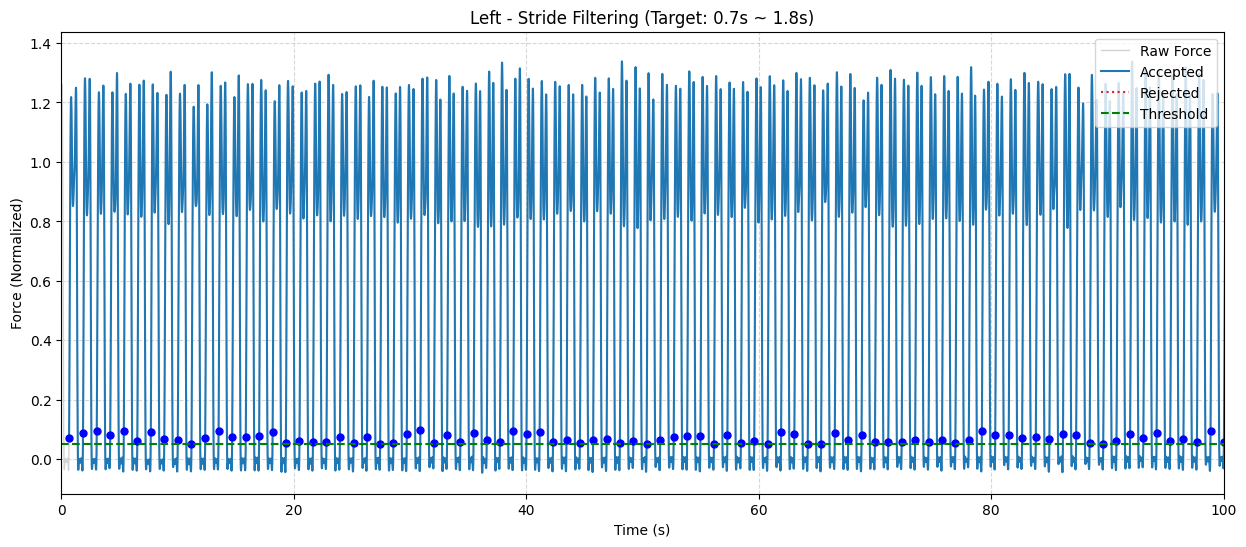


[Right] Processing Result:
  Total Detections : 260
  Accepted Strides : 258 (Range: 0.7-1.8s)
  Rejected Strides : 0


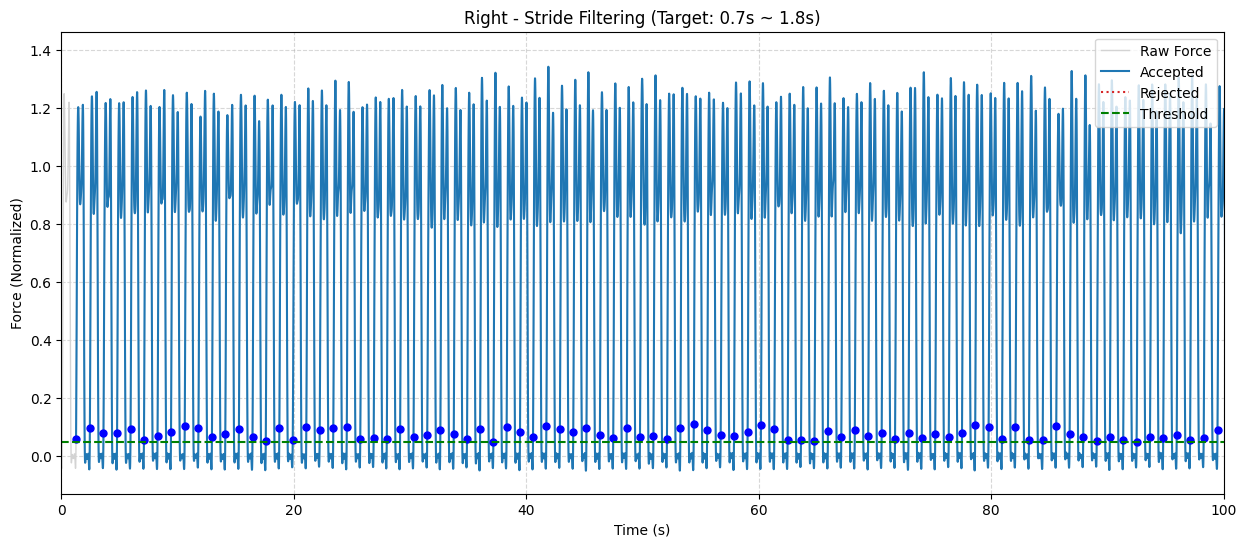

In [13]:
def detect_fz_heel_strikes(signal_array, threshold=0.05, min_dist_samples=40):
    """
    Fzの立ち上がり検出 
    """
    is_contact = signal_array > threshold
    rising_edge = np.diff(is_contact.astype(int), prepend=0) == 1
    potential_indices = np.where(rising_edge)[0]
    
    if len(potential_indices) == 0:
        return np.array([])

    true_indices = [potential_indices[0]]
    for idx in potential_indices[1:]:
        if idx - true_indices[-1] > min_dist_samples:
            true_indices.append(idx)
            
    return np.array(true_indices)

def slice_strides_with_constraints(df_input, target_col, side_name="Left", 
                                   threshold=0.05, fs=100, 
                                   min_duration=0.7, max_duration=1.8, 
                                   show_plot=True):
    """
    ストライド時間の制約を満たす歩行のみを抽出し、
    除外された長さはコンソールにのみ表示する関数
    """
    signal = df_input[target_col].values
    time_array = df_input['Time (Seconds)'].values
    
    min_dist_samples = int(0.4 * fs)
    
    # 1. 接地候補を検出
    hs_indices = detect_fz_heel_strikes(signal, threshold=threshold, min_dist_samples=min_dist_samples)
    
    valid_strides = []      # 採用リスト
    rejected_intervals = [] # 除外リスト (start, end, duration)
    valid_intervals = []    # 採用区間情報 (start, end)

    # 2. ストライドごとに時間を測ってフィルタリング(はじめと最後のストライドを除外)
    for i in range(1, len(hs_indices) - 2):
        start_idx = hs_indices[i]
        end_idx = hs_indices[i+1]
        
        start_t = time_array[start_idx]
        end_t = time_array[end_idx]
        duration = end_t - start_t
        
        # --- 判定ロジック ---
        if min_duration <= duration <= max_duration:
            # 採用
            stride_df = df_input.iloc[start_idx:end_idx].copy()
            valid_strides.append(stride_df)
            valid_intervals.append((start_t, end_t))
        else:
            # 不採用
            rejected_intervals.append((start_t, end_t, duration))

    # --- 結果の表示 (コンソール) ---
    print(f"\n[{side_name}] Processing Result:")
    print(f"  Total Detections : {len(hs_indices)-1}")
    print(f"  Accepted Strides : {len(valid_strides)} (Range: {min_duration}-{max_duration}s)")
    print(f"  Rejected Strides : {len(rejected_intervals)}")
    
    if rejected_intervals:
        # 除外された秒数をリスト化して表示
        rej_durations = [round(r[2], 3) for r in rejected_intervals]
        print(f"  -> Rejected Durations (sec): {rej_durations}")

    # --- 結果の可視化 (プロット) ---
    if show_plot and len(hs_indices) > 0:
        plt.figure(figsize=(15, 6))
        
        # 全体波形
        plt.plot(time_array, signal, color='lightgray', label='Raw Force', linewidth=1)
        
        # 採用区間 (青)
        for (t_s, t_e) in valid_intervals:
            mask = (time_array >= t_s) & (time_array <= t_e)
            plt.plot(time_array[mask], signal[mask], color='tab:blue', linewidth=1.5)
            # 開始点
            idx_s = np.searchsorted(time_array, t_s)
            plt.plot(t_s, signal[idx_s], 'bo', markersize=5)

        # 除外区間 (赤・点線) - テキストは表示しない
        for (t_s, t_e, dur) in rejected_intervals:
            mask = (time_array >= t_s) & (time_array <= t_e)
            plt.plot(time_array[mask], signal[mask], color='tab:red', linestyle=':', alpha=0.8)

        # 凡例・ラベル
        plt.plot([], [], color='tab:blue', label='Accepted')
        plt.plot([], [], color='tab:red', linestyle=':', label='Rejected')
        plt.axhline(y=threshold, color='green', linestyle='--', label='Threshold')

        plt.title(f"{side_name} - Stride Filtering (Target: {min_duration}s ~ {max_duration}s)")
        plt.xlabel("Time (s)")
        plt.ylabel("Force (Normalized)")
        plt.legend(loc='upper right')
        
        # 最初の30秒を表示
        display_end = min(time_array[-1], time_array[0] + 30)
        plt.xlim(0,100)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()

    return valid_strides

# ==========================================
# 実行
# ==========================================
FORCE_THRESHOLD = 0.05

# 左足
left_strides_clean = slice_strides_with_constraints(
    df_input=df_final_analysis,
    target_col='Left_Fz',
    side_name="Left",
    threshold=FORCE_THRESHOLD,
    show_plot=True
)

# 右足
right_strides_clean = slice_strides_with_constraints(
    df_input=df_final_analysis,
    target_col='Right_Fz',
    side_name="Right",
    threshold=FORCE_THRESHOLD,
    show_plot=True
)

In [14]:
# ==========================================
# 1. カラム定義
# ==========================================
# 左側のカラムリスト（Time以外）
cols_left = [
    'Left_Pressure_1', 'Left_Pressure_2', 'Left_Pressure_3', 'Left_Pressure_4', 
    'Left_Pressure_5', 'Left_Pressure_6', 'Left_Pressure_7', 'Left_Pressure_8',
    'Left_Accel_X', 'Left_Accel_Y', 'Left_Accel_Z', 
    'Left_Gyro_X', 'Left_Gyro_Y', 'Left_Gyro_Z', 
    'Left_Hip_Flex_Ext','Left_Hip_Abd_Add', 'Left_Hip_Int_Ext_Rot', 
    'Left_Knee_Flex_Ext','Left_Knee_Abd_Add', 'Left_Knee_Int_Ext_Rot', 
    'Left_Ankle_Flex_Ext','Left_Ankle_Abd_Add', 'Left_Ankle_Int_Ext_Rot',
    'Left_Fx', 'Left_Fy', 'Left_Fz'
]

# 右側のカラムリスト（Left→Right, L_→R_ に置換）
cols_right = [c.replace('Left', 'Right') for c in cols_left]

# ==========================================
# 2. 正規化関数の定義
# ==========================================
def normalize_strides(stride_list, target_cols, n_points=200):
    """
    各ストライドのデータを0-100% (n_points) に正規化する関数
    
    Returns:
        normalized_dfs: 正規化されたDataFrameのリスト
        ensemble_array: 計算用3次元配列 (ストライド数 x 200 x カラム数)
    """
    normalized_dfs = []
    
    # データ格納用リスト（後で3次元配列にするため）
    data_collector = []

    # 0%から100%までの新しい時間軸
    gait_cycle = np.linspace(0, 100, n_points)
    
    # 補間用の新しいx軸 (0.0 ～ 1.0)
    x_new = np.linspace(0, 1, n_points)

    for stride_df in stride_list:
        # このストライドのデータ長
        n_len = len(stride_df)
        
        # 元のx軸 (0.0 ～ 1.0)
        x_old = np.linspace(0, 1, n_len)
        
        # 新しいDataFrame作成
        new_df = pd.DataFrame()
        new_df['Gait Cycle (%)'] = gait_cycle
        
        # 各カラムを補間
        stride_matrix = [] # このストライドの数値データ行列
        
        for col in target_cols:
            if col in stride_df.columns:
                y_old = stride_df[col].values
                
                # 線形補間関数を作成
                f = interp1d(x_old, y_old, kind='linear', fill_value="extrapolate")
                
                # 新しいデータ点での値を取得
                y_new = f(x_new)
                
                new_df[col] = y_new
                stride_matrix.append(y_new)
            else:
                # カラムが無い場合の安全策（全て0埋めなど）
                print(f"Warning: Column {col} not found in stride data.")
                zeros = np.zeros(n_points)
                new_df[col] = zeros
                stride_matrix.append(zeros)
        
        normalized_dfs.append(new_df)
        
        # 転置して (200, カラム数) の形にする
        data_collector.append(np.array(stride_matrix).T)

    # 3次元配列に変換 (ストライド数, 200, カラム数)
    if len(data_collector) > 0:
        ensemble_array = np.array(data_collector)
    else:
        ensemble_array = np.empty((0, n_points, len(target_cols)))

    return normalized_dfs, ensemble_array

# ==========================================
# 3. 実行
# ==========================================

# 左足の正規化
left_norm_dfs, left_ensemble = normalize_strides(
    left_strides_clean, 
    cols_left, 
    n_points=200
)

# 右足の正規化
right_norm_dfs, right_ensemble = normalize_strides(
    right_strides_clean, 
    cols_right, 
    n_points=200
)

# --- 結果の確認 ---
print(f"Left Normalized Strides: {len(left_norm_dfs)}")
print(f"Left Ensemble Shape: {left_ensemble.shape}  (Strides, Points, Features)")

print(f"Right Normalized Strides: {len(right_norm_dfs)}")
print(f"Right Ensemble Shape: {right_ensemble.shape} (Strides, Points, Features)")

# 左足のカラム名を確認
if len(left_norm_dfs) > 0:
    print("=== Left Normalized Columns ===")
    print(left_norm_dfs[0].columns.tolist())

# 右足のカラム名を確認
if len(right_norm_dfs) > 0:
    print("\n=== Right Normalized Columns ===")
    print(right_norm_dfs[0].columns.tolist())

Left Normalized Strides: 259
Left Ensemble Shape: (259, 200, 26)  (Strides, Points, Features)
Right Normalized Strides: 258
Right Ensemble Shape: (258, 200, 26) (Strides, Points, Features)
=== Left Normalized Columns ===
['Gait Cycle (%)', 'Left_Pressure_1', 'Left_Pressure_2', 'Left_Pressure_3', 'Left_Pressure_4', 'Left_Pressure_5', 'Left_Pressure_6', 'Left_Pressure_7', 'Left_Pressure_8', 'Left_Accel_X', 'Left_Accel_Y', 'Left_Accel_Z', 'Left_Gyro_X', 'Left_Gyro_Y', 'Left_Gyro_Z', 'Left_Hip_Flex_Ext', 'Left_Hip_Abd_Add', 'Left_Hip_Int_Ext_Rot', 'Left_Knee_Flex_Ext', 'Left_Knee_Abd_Add', 'Left_Knee_Int_Ext_Rot', 'Left_Ankle_Flex_Ext', 'Left_Ankle_Abd_Add', 'Left_Ankle_Int_Ext_Rot', 'Left_Fx', 'Left_Fy', 'Left_Fz']

=== Right Normalized Columns ===
['Gait Cycle (%)', 'Right_Pressure_1', 'Right_Pressure_2', 'Right_Pressure_3', 'Right_Pressure_4', 'Right_Pressure_5', 'Right_Pressure_6', 'Right_Pressure_7', 'Right_Pressure_8', 'Right_Accel_X', 'Right_Accel_Y', 'Right_Accel_Z', 'Right_Gyro_X'

In [15]:
def filter_outlier_strides(ensemble_array, stride_dfs, n_sigmas=3, outlier_ratio_threshold=0.05):
    """
    全ストライドの中央値から大きく乖離している「外れ値ストライド」を除外する関数
    
    Parameters:
    - ensemble_array: 3次元配列 (ストライド数, 200, カラム数)
    - stride_dfs: 正規化済みDataFrameのリスト (長さはストライド数と同じ)
    - n_sigmas: 閾値 (標準偏差の何倍を許容するか。通常3)
    - outlier_ratio_threshold: 
        1ストライドの中で、全データ点のうち何割が閾値を超えたら「除外」とするか。
        0.0 (0%)  -> 1点でも外れたら即除外 (厳格)
        0.05 (5%) -> 全体の5%以上の点が外れていたら除外 (ノイズ許容)
        
    Returns:
    - clean_ensemble: 除外後の3次元配列
    - clean_dfs: 除外後のDataFrameリスト
    - keep_indices: どのインデックスを残したかのBoolean配列
    """
    
    # 1. 集団の基準を作成 (各時間点・各カラムごとの中央値と標準偏差)
    # axis=0 は「ストライド方向」に計算することを意味します
    median_curve = np.median(ensemble_array, axis=0) # Shape: (200, cols)
    std_curve = np.std(ensemble_array, axis=0)       # Shape: (200, cols)
    
    # 2. 許容範囲 (トンネル) を定義
    upper_limit = median_curve + (n_sigmas * std_curve)
    lower_limit = median_curve - (n_sigmas * std_curve)
    
    # ブロードキャスト計算のために次元を合わせる
    # upper_limit shape: (1, 200, cols)
    upper_limit_bc = upper_limit[np.newaxis, :, :]
    lower_limit_bc = lower_limit[np.newaxis, :, :]
    
    # 3. 外れ値判定 (Trueなら外れ値)
    # Shape: (ストライド数, 200, カラム数)
    is_outlier_matrix = (ensemble_array > upper_limit_bc) | (ensemble_array < lower_limit_bc)
    
    # 4. ストライドごとの判定
    # 各ストライドにおいて、「外れ値」と判定されたデータ点の総数をカウント
    # axis=(1, 2) で 時間×カラム 全体での外れ値数を数えます
    total_points_per_stride = ensemble_array.shape[1] * ensemble_array.shape[2]
    outlier_counts = np.sum(is_outlier_matrix, axis=(1, 2))
    
    # 外れ値の割合を計算
    outlier_ratios = outlier_counts / total_points_per_stride
    
    # 閾値を超えているストライドは False (削除), それ以外は True (保持)
    keep_mask = outlier_ratios <= outlier_ratio_threshold
    
    # 5. フィルタリング実行
    clean_ensemble = ensemble_array[keep_mask]
    
    # DataFrameリストも同じマスクでフィルタリング
    clean_dfs = [df for i, df in enumerate(stride_dfs) if keep_mask[i]]
    
    return clean_ensemble, clean_dfs, keep_mask

# ==========================================
# 実行部分
# ==========================================

# 左足のクリーニング
# outlier_ratio_threshold=0.01 (全体の1%以上の点が異常ならそのストライドを捨てる)
L_ens_clean, L_dfs_clean, L_mask = filter_outlier_strides(
    left_ensemble, 
    left_norm_dfs, 
    n_sigmas=3, 
    outlier_ratio_threshold=0.01 
)

# 右足のクリーニング
R_ens_clean, R_dfs_clean, R_mask = filter_outlier_strides(
    right_ensemble, 
    right_norm_dfs, 
    n_sigmas=3, 
    outlier_ratio_threshold=0.01
)

# --- 結果確認 ---
print("=== Cleaning Result ===")
print(f"Left Stride Count:  {len(left_norm_dfs)} -> {len(L_dfs_clean)} (Removed: {len(left_norm_dfs) - len(L_dfs_clean)})")
print(f"Right Stride Count: {len(right_norm_dfs)} -> {len(R_dfs_clean)} (Removed: {len(right_norm_dfs) - len(R_dfs_clean)})")

print(f"Left Ensemble Shape: {L_ens_clean.shape}")
print(f"Right Ensemble Shape: {R_ens_clean.shape}")

=== Cleaning Result ===
Left Stride Count:  259 -> 203 (Removed: 56)
Right Stride Count: 258 -> 200 (Removed: 58)
Left Ensemble Shape: (203, 200, 26)
Right Ensemble Shape: (200, 200, 26)


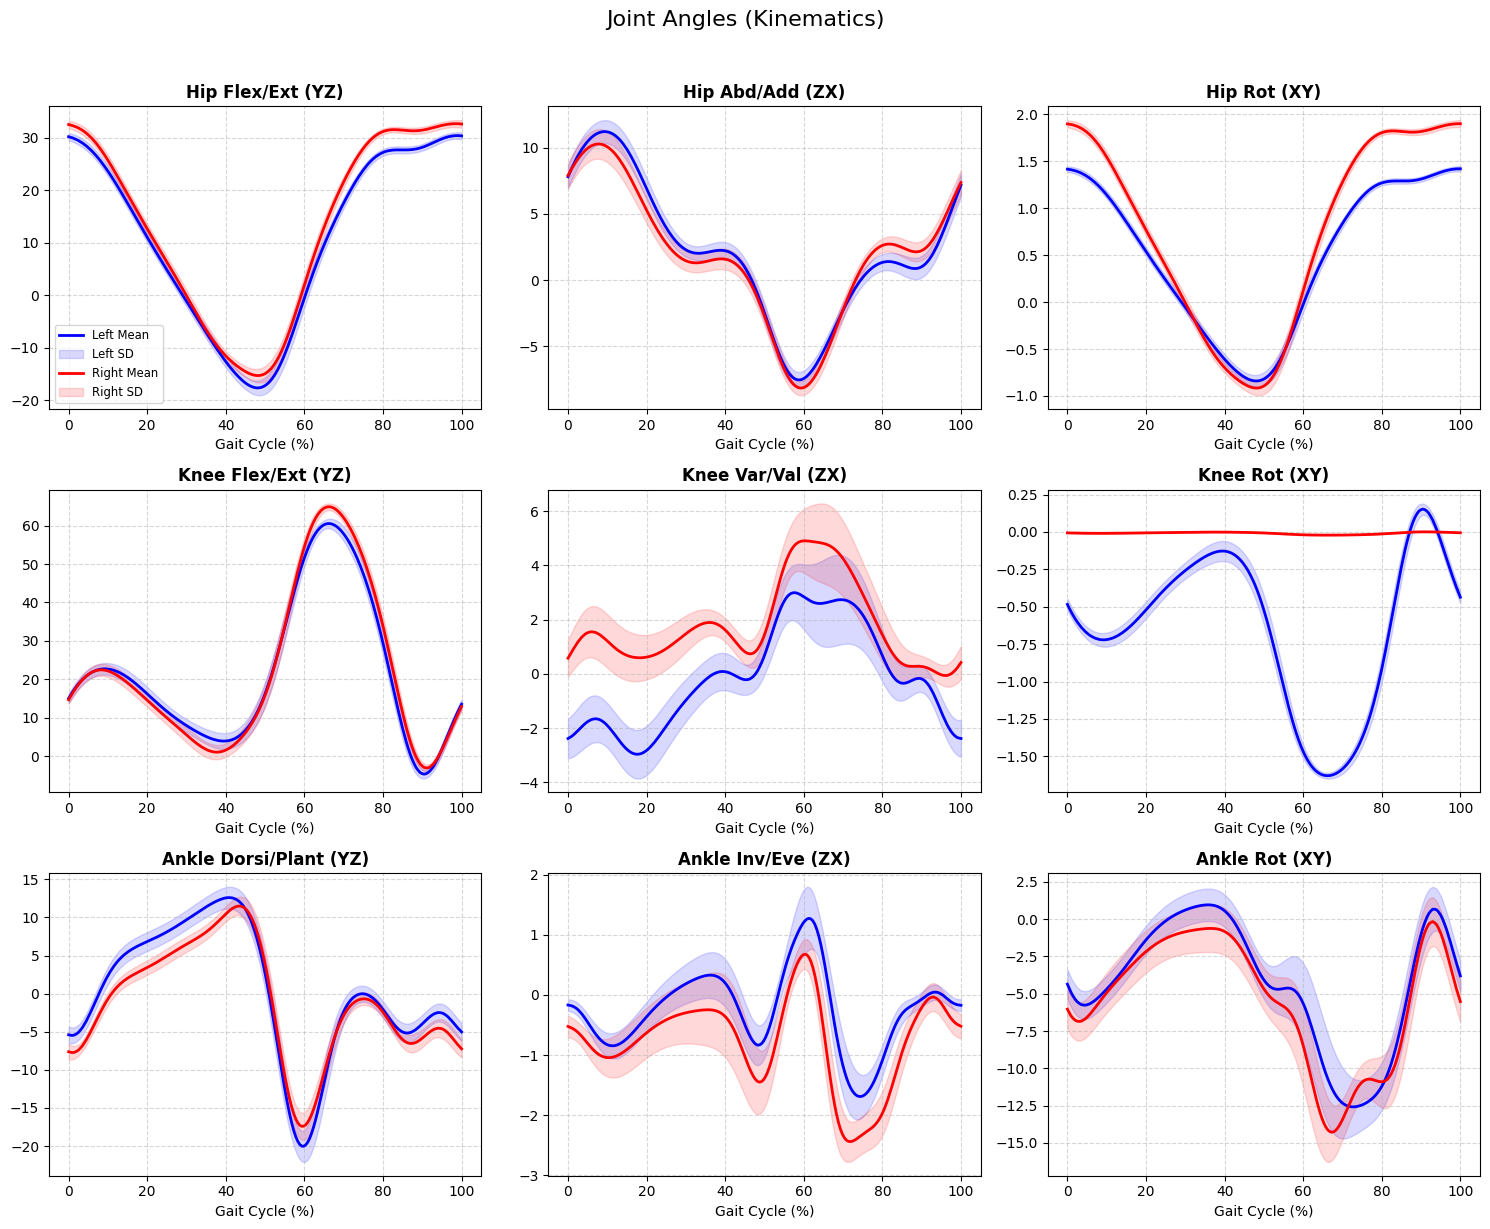

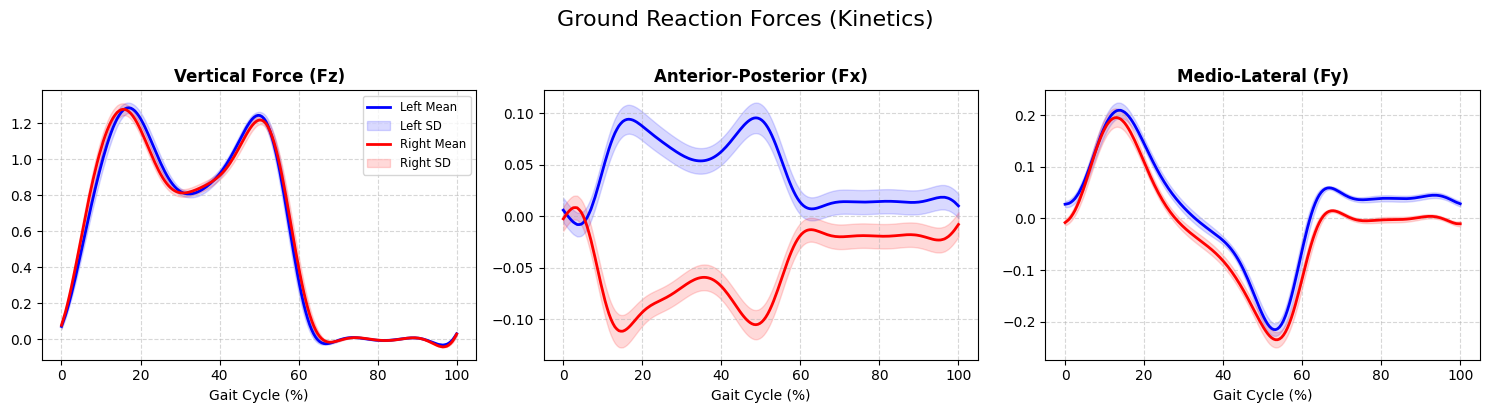

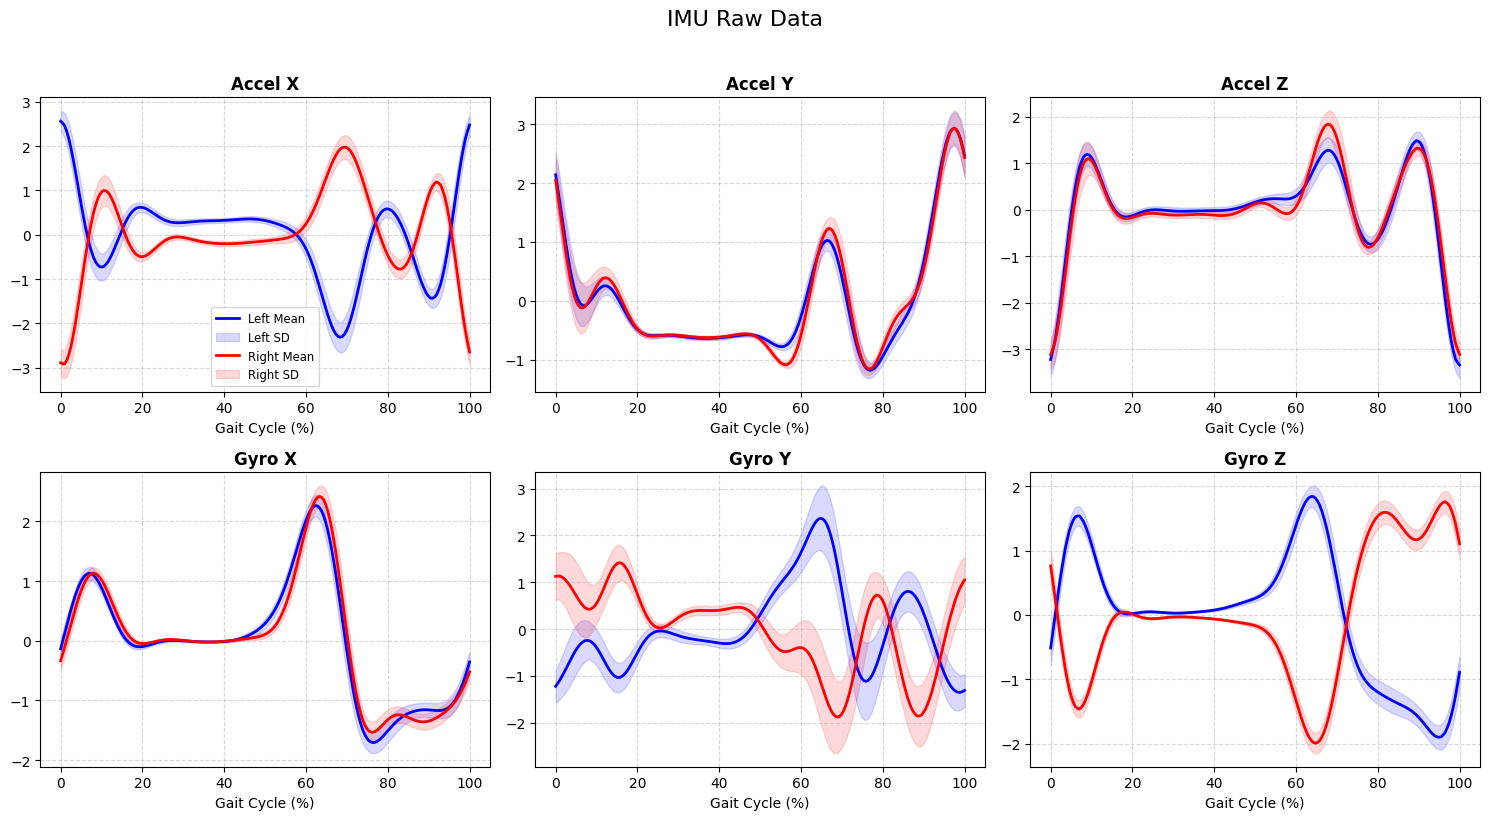

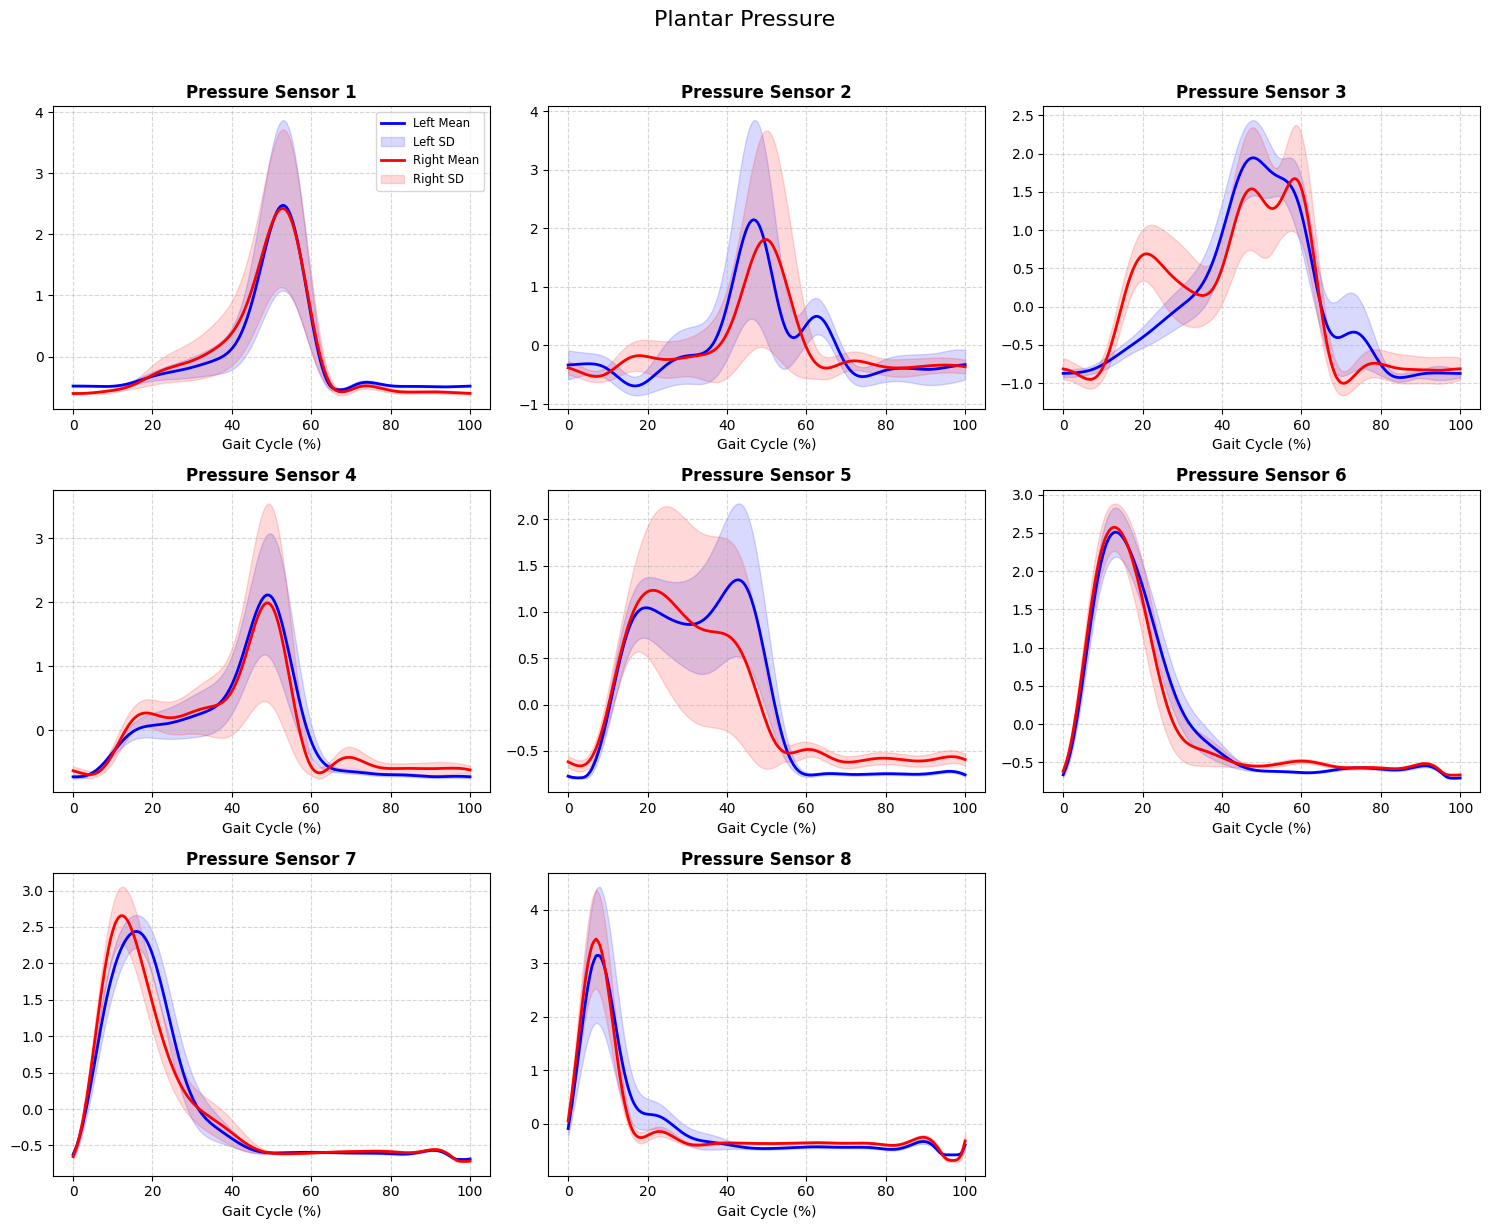

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def plot_gait_comparison(left_ensemble, right_ensemble, 
                         left_cols, right_cols, 
                         target_features_map, 
                         title="Gait Analysis"):
    """
    左右の正規化データを比較プロットする関数
    
    Parameters:
    - left_ensemble, right_ensemble: (Strides, 200, Features) の3次元配列
    - left_cols, right_cols: カラム名のリスト
    - target_features_map: プロットしたい項目の辞書 {'タイトル': ('Left名', 'Right名')}
    """
    
    # プロットの行・列数を計算
    n_plots = len(target_features_map)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()
    
    # 0-100% の軸
    x = np.linspace(0, 100, 200)
    
    for i, (plot_title, (l_col, r_col)) in enumerate(target_features_map.items()):
        ax = axes[i]
        
        # --- 左足 (Blue) ---
        if l_col in left_cols:
            idx = left_cols.index(l_col)
            # 全ストライドのデータ (N, 200)
            data_l = left_ensemble[:, :, idx]
            
            mean_l = np.mean(data_l, axis=0)
            std_l = np.std(data_l, axis=0)
            
            ax.plot(x, mean_l, color='blue', label='Left Mean', linewidth=2)
            ax.fill_between(x, mean_l - std_l, mean_l + std_l, color='blue', alpha=0.15, label='Left SD')
            
        # --- 右足 (Red) ---
        if r_col in right_cols:
            idx = right_cols.index(r_col)
            # 全ストライドのデータ (N, 200)
            data_r = right_ensemble[:, :, idx]
            
            mean_r = np.mean(data_r, axis=0)
            std_r = np.std(data_r, axis=0)
            
            ax.plot(x, mean_r, color='red', label='Right Mean', linewidth=2)
            ax.fill_between(x, mean_r - std_r, mean_r + std_r, color='red', alpha=0.15, label='Right SD')

        ax.set_title(plot_title, fontsize=12, fontweight='bold')
        ax.set_xlabel("Gait Cycle (%)")
        ax.grid(True, linestyle='--', alpha=0.5)
        
        # 凡例は最初のグラフにだけ表示（ごちゃつき防止）
        if i == 0:
            ax.legend(loc='best', fontsize='small')

    # 余ったサブプロットを消す
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# ==========================================
# 1. 関節角度の可視化 (Joint Angles)
# ==========================================
# 表示したいペアを定義 {'グラフタイトル': ('左カラム名', '右カラム名')}
angle_map = {
    # 屈曲・伸展 (Flexion/Extension) -> 矢状面 (Sagittal) -> YZ
    'Hip Flex/Ext (YZ)':   ('Left_Hip_Flex_Ext', 'Right_Hip_Flex_Ext'),
    # 外転・内転 (Abduction/Adduction) -> 前額面 (Frontal) -> ZX
    'Hip Abd/Add (ZX)':    ('Left_Hip_Abd_Add', 'Right_Hip_Abd_Add'),
    # 回旋 (Rotation) -> 水平面 (Horizontal) -> XY
    'Hip Rot (XY)':        ('Left_Hip_Int_Ext_Rot', 'Right_Hip_Int_Ext_Rot'),
    
    # 膝関節
    'Knee Flex/Ext (YZ)':  ('Left_Knee_Flex_Ext', 'Right_Knee_Flex_Ext'),
    'Knee Var/Val (ZX)':   ('Left_Knee_Abd_Add', 'Right_Knee_Abd_Add'), # 内反・外反は前額面
    'Knee Rot (XY)':       ('Left_Knee_Int_Ext_Rot', 'Right_Knee_Int_Ext_Rot'), # 回旋は水平面

    # 足関節
    'Ankle Dorsi/Plant (YZ)': ('Left_Ankle_Flex_Ext', 'Right_Ankle_Flex_Ext'), # 背屈・底屈は矢状面
    'Ankle Inv/Eve (ZX)':     ('Left_Ankle_Abd_Add', 'Right_Ankle_Abd_Add'), # 内返し・外返しは主に前額面（または複合）
    'Ankle Rot (XY)':         ('Left_Ankle_Int_Ext_Rot', 'Right_Ankle_Int_Ext_Rot'), # 外転・内転（回旋要素）
}

plot_gait_comparison(
    L_ens_clean, R_ens_clean, 
    cols_left, cols_right, 
    angle_map, 
    title="Joint Angles (Kinematics)"
)

# ==========================================
# 2. 床反力の可視化 (Ground Reaction Forces)
# ==========================================
force_map = {
    'Vertical Force (Fz)': ('Left_Fz', 'Right_Fz'),
    'Anterior-Posterior (Fx)': ('Left_Fx', 'Right_Fx'),
    'Medio-Lateral (Fy)':  ('Left_Fy', 'Right_Fy'),
}

plot_gait_comparison(
    L_ens_clean, R_ens_clean, 
    cols_left, cols_right, 
    force_map, 
    title="Ground Reaction Forces (Kinetics)"
)

# ==========================================
# 3. IMUデータの可視化 (Accel & Gyro)
# ==========================================
imu_map = {
    'Accel X': ('Left_Accel_X', 'Right_Accel_X'),
    'Accel Y': ('Left_Accel_Y', 'Right_Accel_Y'),
    'Accel Z': ('Left_Accel_Z', 'Right_Accel_Z'),
    'Gyro X':  ('Left_Gyro_X', 'Right_Gyro_X'),
    'Gyro Y':  ('Left_Gyro_Y', 'Right_Gyro_Y'),
    'Gyro Z':  ('Left_Gyro_Z', 'Right_Gyro_Z'),
}

plot_gait_comparison(
    L_ens_clean, R_ens_clean, 
    cols_left, cols_right, 
    imu_map, 
    title="IMU Raw Data"
)

# ==========================================
# 4. 足底圧の可視化 (Plantar Pressure)
# ==========================================
# センサー1〜8の左右比較マップを作成
pressure_map = {}
for i in range(1, 9):
    pressure_map[f'Pressure Sensor {i}'] = (f'Left_Pressure_{i}', f'Right_Pressure_{i}')

# プロット実行
plot_gait_comparison(
    L_ens_clean, R_ens_clean, 
    cols_left, cols_right, 
    pressure_map, 
    title="Plantar Pressure"
)

/var/folders/8y/sxggcqcd107gk_q502z3vggh0000gn/T/ipykernel_90779/2506496999.py:79: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best') # 凡例の位置を自動調整


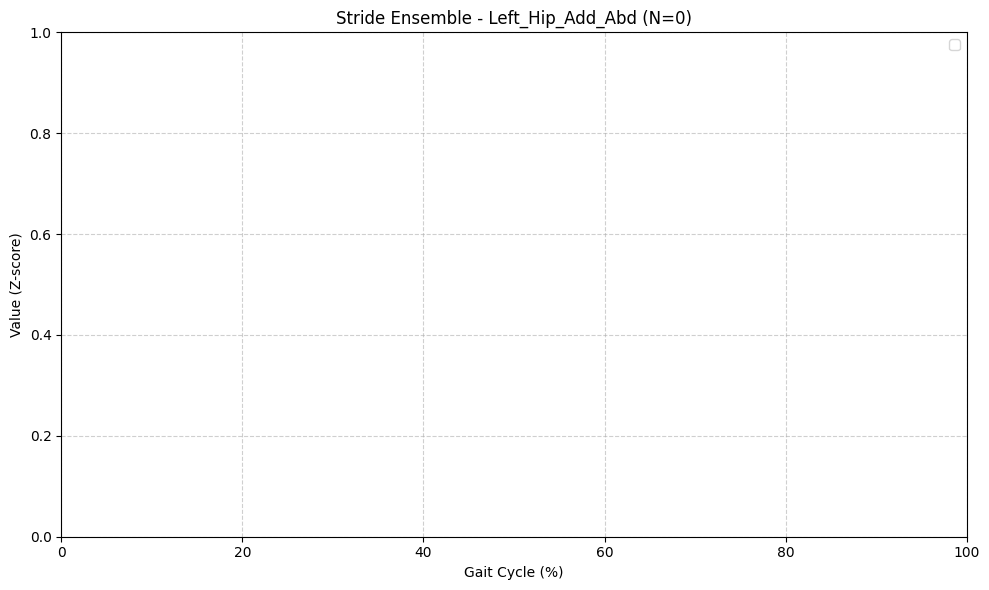

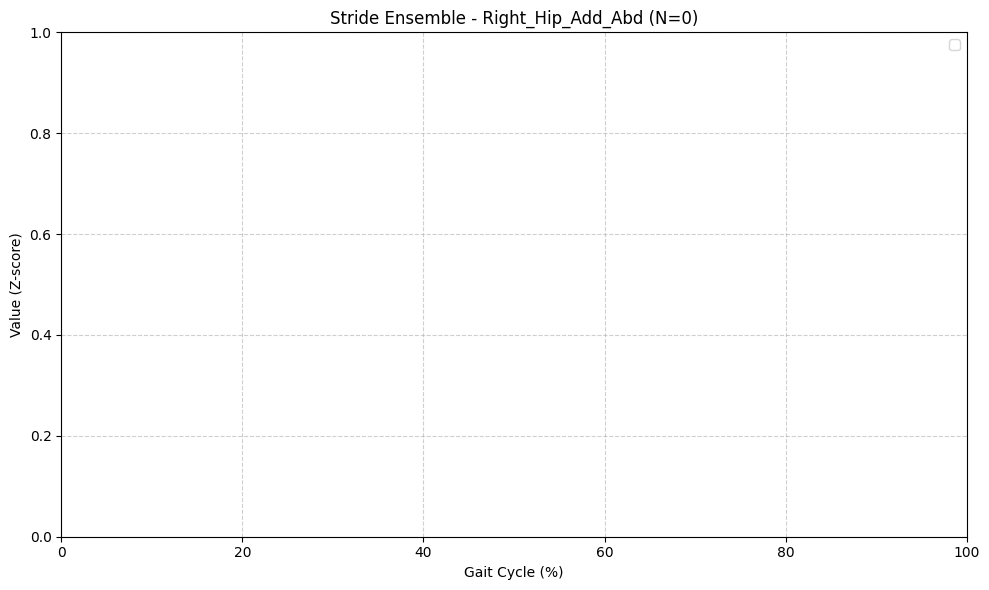

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ensemble_strides(stride_list, target_col, title="Stride Ensemble", unit="Z-score", y_limits=None):
    """
    複数のストライドデータを0-100%に正規化して重ね書きする関数
    
    Parameters:
    - stride_list: 切り出されたDataFrameのリスト
    - target_col: プロットしたいカラム名
    - title: グラフのタイトル
    - unit: Y軸の単位ラベル
    - y_limits: Y軸の範囲指定 (min, max) ※左右比較などで範囲を揃えたい時に使用
    """
    if not stride_list:
        print(f"No strides to plot for {target_col}.")
        return

    # 正規化後のデータ点数
    norm_length = 101
    x_norm = np.linspace(0, 100, norm_length)
    
    ensemble_data = []

    plt.figure(figsize=(10, 6))

    # --- 1. 個別のストライドをプロット ---
    # データ処理とプロットを分け、アンサンブル計算を先に行うことも可能ですが、
    # 視覚的には薄いグレー(個別)の上に赤(平均)が来るように描画順を意識します。
    
    count = 0
    for df in stride_list:
        if target_col not in df.columns:
            continue
            
        y_values = df[target_col].values
        
        if len(y_values) < 2:
            continue

        # 時間軸の正規化
        x_original = np.linspace(0, 100, len(y_values))
        y_interp = np.interp(x_norm, x_original, y_values)
        
        ensemble_data.append(y_interp)
        count += 1

        # 個別データのプロット
        plt.plot(x_norm, y_interp, color='gray', alpha=0.3, linewidth=0.8)

    # --- 2. 平均波形の計算とプロット ---
    if ensemble_data:
        ensemble_matrix = np.array(ensemble_data)
        
        mean_waveform = np.mean(ensemble_matrix, axis=0)
        std_waveform = np.std(ensemble_matrix, axis=0)
        
        # 標準偏差の範囲（塗りつぶし）- 平均線の下に描画されるようzorder調整も有効ですが、今回は順序で対応
        plt.fill_between(x_norm, 
                         mean_waveform - std_waveform, 
                         mean_waveform + std_waveform, 
                         color='red', alpha=0.15, label='±1 SD')
        
        # 平均値
        plt.plot(x_norm, mean_waveform, color='red', linewidth=3, label='Mean')

    # --- 3. グラフの装飾 ---
    # タイトルにデータ数(N)を含めるのが研究用グラフのポイントです
    plt.title(f"{title} - {target_col} (N={count})")
    plt.xlabel("Gait Cycle (%)")
    plt.ylabel(f"Value ({unit})")
    plt.xlim(0, 100)
    
    # Y軸範囲の指定があれば適用（左右の足を比較する際などに便利）
    if y_limits:
        plt.ylim(y_limits)
        
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='best') # 凡例の位置を自動調整
    
    # 一般的に立脚相と遊脚相の境目（約60%）に目安線を入れることもあります（必要に応じて）
    # plt.axvline(x=60, color='black', linestyle=':', alpha=0.5, label='Toe Off approx.')

    plt.tight_layout() # レイアウトの自動調整
    plt.show()

# ==========================================
# 実行例（データ変数がメモリにあると仮定）
# ==========================================
# Left
plot_ensemble_strides(
    stride_list=left_strides_clean, 
    target_col='Left_Hip_Add_Abd', 
)

# Right
plot_ensemble_strides(
    stride_list=right_strides_clean, 
    target_col='Right_Hip_Add_Abd', 
)